In [1]:
# --------------------------------------------------
# 1. Imports (add these to the existing ones)
# --------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
from torchvision.transforms import Resize
from ast import literal_eval
from sklearn.metrics import matthews_corrcoef
from torchvision import models
from transformers import AutoTokenizer, AutoModelForMaskedLM
import math
import json
from collections import defaultdict
import seaborn as sns
from matplotlib.colors import LogNorm
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import logomaker
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA

# --------------------------------------------------

In [2]:
DEVICE    = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Reading data

In [3]:
test_df = pd.read_csv('../../test_classification.csv', index_col=0)

In [4]:
test_df.columns

Index(['sequence', 'anti-bacterial', 'anti-cancer', 'anti-fungal',
       'anti-parasitic', 'anti-viral', 'cell-cell-communication',
       'drug-delivery', 'immunological', 'inhibitor', 'metabolic',
       'non-functional', 'other-functional', 'signal-peptide', 'toxic'],
      dtype='object')

In [5]:
test_df.head()

,sequence,anti-bacterial,anti-cancer,anti-fungal,anti-parasitic,anti-viral,cell-cell-communication,drug-delivery,immunological,inhibitor,metabolic,non-functional,other-functional,signal-peptide,toxic
0,MNLNKQVAIVTGGASGFGAAIARRLSQAGAAVLVADLNAEGAQRMA...,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,MSLLTPDIGLLFWMLLSFGIVFFVAAKYGFPVIVKMVDERNAFINK...,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,MSSTWIKFLFILTLVLLPYFVAESAVASPESLRKVPNCTLYKSESD...,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,APTSSPAKETQQHLEQLLLDLQVLLRGIDNYKNLKLPMMLTFKFYL...,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,MEVDILSEDENSMLHRTDIQFEIAHEDATPSRLSVRDSLAAKINKD...,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [6]:
non_func_test_sub_seq = []
with open("../../test_non_func_predict_subseqs_after_cd_hit.txt") as f:
    for seq in f.readlines():
        non_func_test_sub_seq.append(seq.strip())

In [7]:
peptides_data = []
for i, row in test_df.iterrows():
    seq = row['sequence']
    classes = {}
    for c in ['anti-bacterial', 'anti-cancer', 'anti-fungal',
       'anti-parasitic', 'anti-viral', 'cell-cell-communication',
       'drug-delivery', 'immunological', 'inhibitor', 'metabolic',
       'non-functional', 'other-functional', 'signal-peptide', 'toxic']:
        classes[c] = row[c]
    
    classes['pseudo-non-functional'] = False
    peptides_data.append({'sequence': seq, "classes": classes})

In [8]:
for seq in non_func_test_sub_seq:
    classes = {c: False for c in ['anti-bacterial', 'anti-cancer', 'anti-fungal',
       'anti-parasitic', 'anti-viral', 'cell-cell-communication',
       'drug-delivery', 'immunological', 'inhibitor', 'metabolic',
       'non-functional', 'other-functional', 'signal-peptide', 'toxic']}
    
    classes['pseudo-non-functional'] = True
    classes['non-functional'] = True
    peptides_data.append({'sequence': seq, "classes": classes})

In [9]:
class PeptideDataset(Dataset):

    def __init__(
        self,
        data,
        tokenizer,
        max_length: int = 128
    ):

        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length



    def __len__(self) -> int:
        """Returns the total number of samples in the dataset."""
        return len(self.data)

    def __getitem__(self, index: int):
        sequence = self.data[index]['sequence']
        classes = self.data[index]['classes']
        encodings = self.tokenizer(
            sequence,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )


        return {
            'input_ids': encodings['input_ids'][0],
            'attention_mask': encodings['attention_mask'][0],
            'labels': classes,
            'sequence': sequence
        }

In [10]:
esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
MAX_LEN = 100

dataset = PeptideDataset(data=peptides_data, tokenizer=esm_tokenizer, max_length=MAX_LEN)

In [11]:
data_loader = DataLoader(dataset, batch_size=64, shuffle=False)

# Model

In [12]:


class ESM2_Encoder(nn.Module):
    def __init__(self, model_name, trainable=True, unfreeze_last_n=0):
        super().__init__()
        self.esm_mlm = AutoModelForMaskedLM.from_pretrained(model_name)
        self.hidden_size = self.esm_mlm.config.hidden_size
        if not trainable:
            for param in self.esm_mlm.parameters():
                param.requires_grad = False
            if unfreeze_last_n > 0:
                for layer in self.esm_mlm.esm.encoder.layer[-unfreeze_last_n:]:
                    for param in layer.parameters():
                        param.requires_grad = True

    def forward(self, input_ids, attention_mask):
        return self.esm_mlm.esm(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

class SEBlock(nn.Module):
    """
    Mask-aware Squeeze-and-Excitation block.

    Input:
        x        : [B, C, L]
        seq_mask : [B, L], 1 for valid tokens, 0 for PAD

    The channel descriptor is computed using only valid sequence positions.
    """

    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 1)

        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(),
            nn.Linear(hidden, channels),
            nn.Sigmoid()
        )

    def forward(self, x, seq_mask):
        # [B, L] -> [B, 1, L]
        mask = seq_mask.unsqueeze(1).to(dtype=x.dtype)

        # Remove PAD contributions
        x_masked = x * mask

        # Number of valid positions per sequence
        lengths = seq_mask.sum(
            dim=1,
            keepdim=True
        ).clamp_min(1).to(dtype=x.dtype)

        # Masked global average pooling over sequence dimension
        # [B, C, L] -> [B, C]
        channel_descriptor = (
            x_masked.sum(dim=-1) / lengths
        )

        # Channel-wise gates
        gates = self.fc(channel_descriptor).unsqueeze(-1)

        # Apply channel recalibration
        return x * gates

class ConvBlock(nn.Module):
    """
    Mask-aware two-layer 1D convolution block.

    Uses LayerNorm instead of BatchNorm so that padded positions
    do not participate in batch/sequence normalization statistics.
    """

    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.norm1 = nn.LayerNorm(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.norm2 = nn.LayerNorm(out_channels)

    @staticmethod
    def apply_layernorm(x, norm):
        """
        Conv output: [B, C, L]
        LayerNorm expects normalized dimension at the end.
        """
        x = x.transpose(1, 2)      # [B, L, C]
        x = norm(x)
        x = x.transpose(1, 2)      # [B, C, L]
        return x

    def forward(self, x, mask):
        """
        x    : [B, C, L]
        mask : [B, 1, L]
        """
        # First convolution
        y = self.conv1(x)
        y = self.apply_layernorm(
            y,
            self.norm1
        )

        y = F.gelu(y)

        # Explicitly remove PAD activations
        y = y * mask

        # Second convolution
        y = self.conv2(y)

        y = self.apply_layernorm(
            y,
            self.norm2
        )

        y = F.gelu(y)

        # Explicitly remove PAD activations again
        y = y * mask

        return y

class EnhancedCNN1D(nn.Module):
    """
    Mask-aware multi-scale CNN for peptide/protein sequences.

    Branches:
        kernel 3 -> effective receptive field 5
        kernel 5 -> effective receptive field 9
        kernel 7 -> effective receptive field 13

    Each branch contains two convolutional layers.

    Output:
        [B, 2 * 3 * conv_dim]

    For conv_dim=128:
        output = [B, 768]
    """

    def __init__(
        self,
        vocab_size=33,
        embed_dim=128,
        conv_dim=128
    ):
        super().__init__()


        # Token embedding
        self.embed = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=1 # ESM TOKENIZER
        )

        # Multi-scale CNN branches
        self.branches = nn.ModuleList([
            ConvBlock(
                in_channels=embed_dim,
                out_channels=conv_dim,
                kernel_size=k
            )
            for k in [3, 5, 7]
        ])

        # Residual projection
        self.res_proj = nn.Conv1d(
            embed_dim,
            conv_dim,
            kernel_size=1,
            bias=False
        )

        # Squeeze-and-Excitation
        self.se = SEBlock(
            channels=conv_dim * 3,
            reduction=4
        )

        self.dropout = nn.Dropout(0.2)

        # Three branches × conv_dim channels
        # Max pooling + mean pooling
        self.hidden_size = conv_dim * 3 * 2

    def forward(self, x, seq_mask):
        """
        Args:
            x:
                [B, L] token IDs

            seq_mask:
                [B, L]
                1 = valid token
                0 = PAD
        Returns:
            CNN feature vector:
                [B, hidden_size]

        For conv_dim=128:
            [B, 768]
        """


        # Validate mask


        if seq_mask is None:
            raise ValueError(
                "seq_mask must be provided to EnhancedCNN1D. "
                "CNN padding masking must never be bypassed."
            )
        # Embedding
        # [B, L] -> [B, L, embed_dim]
        x = self.embed(x)

        # [B, L, embed_dim] -> [B, embed_dim, L]
        x = x.transpose(1, 2)

        # [B, L] -> [B, 1, L]
        mask = seq_mask.unsqueeze(1).to(dtype=x.dtype)

        # Explicitly zero PAD embeddings
        x = x * mask

        # Residual pathway
        res = self.res_proj(x)

        # Remove PAD activations
        res = res * mask

        # Multi-scale branches
        outs = []

        for branch in self.branches:
            y = branch(x, mask)
            # Residual connection
            y = y + res
            # Guarantee PAD = 0 after residual addition
            y = y * mask
            outs.append(y)

        # Concatenate branches
        # [B, 128*3, L]
        combined = torch.cat(
            outs,
            dim=1
        )

        # Guarantee no PAD signal
        combined = combined * mask

        # Mask-aware SE
        combined = self.se(
            combined,
            seq_mask
        )

        # SE can theoretically produce nonzero values
        # at PAD positions, so mask once more.
        combined = combined * mask

        # MASKED GLOBAL MAX POOLING
        # PAD cannot become the maximum.
        combined_for_max = combined.masked_fill(
            seq_mask.unsqueeze(1) == 0,
            torch.finfo(combined.dtype).min
        )

        max_pooled = combined_for_max.max(
            dim=-1
        ).values


        # MASKED GLOBAL MEAN POOLING
        combined_for_mean = combined * mask

        # Actual number of valid tokens
        lengths = seq_mask.sum(
            dim=1,
            keepdim=True
        ).clamp_min(1).to(
            dtype=combined.dtype
        )

        mean_pooled = (
            combined_for_mean.sum(dim=-1)
            / lengths
        )

        # FINAL REPRESENTATION
        pooled = torch.cat(
            [
                max_pooled,
                mean_pooled
            ],
            dim=1
        )

        return self.dropout(pooled)


class MultiHeadAttentionPool(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.attn = nn.Sequential(
            nn.Linear(dim, 128), 
            nn.Tanh(), 
            nn.Linear(128, num_heads)
        )
        self._last_weights = None

    def forward(self, x, mask):
        scores = self.attn(x)
        scores = scores.masked_fill(mask.unsqueeze(-1) == 0, -1e4)
        weights = torch.softmax(scores, dim=1)
        self._last_weights = weights
        pooled = (x.unsqueeze(2) * weights.unsqueeze(-1)).sum(dim=1)
        return pooled.view(x.size(0), -1)


    def orthogonality_loss(self):
        """Penalize overlap between head attention distributions."""
        if self._last_weights is None:
            return 0.0
            
        # weights: [B, L, num_heads] -> transpose to [B, num_heads, L]
        w = self._last_weights.transpose(1, 2)  
        
        # Gram matrix of head attention distributions: shape [B, num_heads, num_heads]
        gram = torch.bmm(w, w.transpose(1, 2))  
        
        # Create a boolean mask for the off-diagonal elements (~torch.eye inverts the identity matrix)
        mask = ~torch.eye(self.num_heads, dtype=torch.bool, device=gram.device)
        
        # Penalize only the off-diagonal overlap to encourage heads to focus on different tokens.
        # We want these dot products to be pushed towards 0.
        loss = (gram[:, mask] ** 2).mean()
        
        return loss
    
class GatedFusion(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid())
    def forward(self, x):
        return x * self.gate(x)

class PeptideNetwork(nn.Module):
    def __init__(self, num_classes=21, mask_token_id=32):
        super().__init__()
        self.mask_token_id = mask_token_id
        self.num_classes = num_classes

        # BOTH encoders are now the 8M parameter t6 model
        self.esm_t6_a = ESM2_Encoder("facebook/esm2_t6_8M_UR50D", trainable=True)        
        self.esm_t6_b = ESM2_Encoder("facebook/esm2_t6_8M_UR50D", trainable=False, unfreeze_last_n=2)                                  
        self.cnn = EnhancedCNN1D()          # Bx768

        # REDUCED cross_dim to 128 to save parameters
        cross_dim = 128
        self.proj_t6_a = nn.Linear(320, cross_dim)
        self.proj_t6_b = nn.Linear(320, cross_dim) # Updated to 320 for t6

        self.cross_t6_a = nn.MultiheadAttention(cross_dim, num_heads=4, batch_first=True, dropout=0.1)
        self.ln_ca_t6_a = nn.LayerNorm(cross_dim)
        
        self.cross_t6_b = nn.MultiheadAttention(cross_dim, num_heads=4, batch_first=True, dropout=0.1)
        self.ln_ca_t6_b = nn.LayerNorm(cross_dim)
        
        self.pool_t6_a = MultiHeadAttentionPool(cross_dim, num_heads=4)
        self.pool_t6_b = MultiHeadAttentionPool(cross_dim, num_heads=4)

        # Bottleneck reduction layer before fusion
        # Concat size: 128*4*3 (pools) + 768 (CNN) = 1536 + 768 = 2304
        concat_size = cross_dim * 4 * 2 + self.cnn.hidden_size
        
        self.dim_reduce = nn.Sequential(
            nn.Linear(concat_size, 512),
            nn.GELU()
        )
        
        # Fusion now operates efficiently on 512 dimensions
        self.fusion = GatedFusion(512)
        self.ln = nn.LayerNorm(512)

        # binary head
        binary_features_dim = 64
        self.binary_features = nn.Sequential(
            nn.Linear(512, binary_features_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        self.binary_classifier = nn.Linear(64, 1) # Final logit

        # Task Query Decoder
        self.task_dim = 128
        self.n_memory_tokens = 16
        self.memory_proj = nn.Sequential(
            nn.Linear(512 + binary_features_dim, self.task_dim * self.n_memory_tokens),
            nn.GELU(),
        )
        self.task_queries = nn.Embedding(num_classes, self.task_dim)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=self.task_dim, nhead=4, dim_feedforward=256,
            batch_first=True, dropout=0.1
        )
        self.task_decoder = nn.TransformerDecoder(decoder_layer, num_layers=2)
        self.task_classifiers = nn.ModuleList([
            nn.Linear(self.task_dim, 1) for _ in range(num_classes)
        ])

    def _mask_tokens(self, input_ids, attention_mask, mask_prob=0.15):
        masked_ids = input_ids.clone()
        prob_matrix = torch.full_like(input_ids, mask_prob, dtype=torch.float)
        prob_matrix[attention_mask == 0] = 0
        prob_matrix[:, 0] = 0
        seq_lens = attention_mask.sum(dim=1)
        for i in range(len(seq_lens)):
            if seq_lens[i] > 1:
                prob_matrix[i, seq_lens[i] - 1] = 0
        mask = torch.bernoulli(prob_matrix).bool()
        masked_ids[mask] = self.mask_token_id
        return masked_ids

    def _extract_features(self, seq_input, seq_mask):
        esm6_a_seq = self.esm_t6_a(seq_input, seq_mask)       
        esm6_b_seq = self.esm_t6_b(seq_input, seq_mask)     
        cnn_feat = self.cnn(seq_input, seq_mask)                            

        t6_a = self.proj_t6_a(esm6_a_seq)       
        t6_b = self.proj_t6_b(esm6_b_seq)    


        kv_pad = seq_mask == 0  

        ca_t6_a, _ = self.cross_t6_a(t6_a, t6_b, t6_b, key_padding_mask=kv_pad)
        ca_t6_a = self.ln_ca_t6_a(t6_a + ca_t6_a)

        ca_t6_b, _ = self.cross_t6_b(t6_b, t6_a, t6_a, key_padding_mask=kv_pad)
        ca_t6_b = self.ln_ca_t6_b(t6_b + ca_t6_b)

        pooled_t6_a = self.pool_t6_a(ca_t6_a, seq_mask)
        pooled_t6_b = self.pool_t6_b(ca_t6_b, seq_mask)

        # Concat -> Reduce -> Fuse
        combined = torch.cat([pooled_t6_a, pooled_t6_b, cnn_feat], dim=1)  
        reduced = self.dim_reduce(combined)
        fusion = self.ln(reduced + self.fusion(reduced))

        binary_features = self.binary_features(fusion)
        
        return binary_features, torch.cat([fusion, binary_features], dim=1)
    
    def _binary_classify(self, binary_features):
        
        binary_logits = self.binary_classifier(binary_features)

        return binary_logits

    def _classify(self, final_fusion):
        B = final_fusion.size(0)
        memory = self.memory_proj(final_fusion).view(B, self.n_memory_tokens, self.task_dim)
        tgt = self.task_queries.weight.unsqueeze(0).expand(B, -1, -1)
        decoded = self.task_decoder(tgt, memory)
        logits = torch.cat([self.task_classifiers[i](decoded[:, i, :])
                           for i in range(self.num_classes)], dim=1)
        return logits

    def forward(self, seq_input, seq_mask, mask_tokens=False):
        if mask_tokens and self.training:
            seq_input = self._mask_tokens(seq_input, seq_mask)
        
        binary_features, combined_features = self._extract_features(seq_input, seq_mask)
        

        return self._binary_classify(binary_features), self._classify(combined_features)


    def ortho_loss(self):
        return (self.pool_t6_a.orthogonality_loss() +
                self.pool_t6_b.orthogonality_loss() 
                ) / 2
    
    def get_features(self, seq_input, seq_mask, mask_tokens=False):
        if mask_tokens and self.training:
            seq_input = self._mask_tokens(seq_input, seq_mask)
        return self._extract_features(seq_input, seq_mask)

    def multi_classify(self, combined):
        return self._classify(combined)
    
    def binary_classify(self, binary_features):
        return self._binary_classify(binary_features)


    
    @torch.no_grad()
    def get_attention_weights(self, seq_input, seq_mask):
        """
        Passes data through the network and returns the sequence-level 
        attention weights from the MultiHeadAttentionPool layers.
        """


        # 1. Extract features using the standard helper method
        binary_features, combined_features = self._extract_features(seq_input, seq_mask)
        
        # 2. Extract the weights [Batch, Seq_Len, num_heads]
        weights_a = self.pool_t6_a._last_weights 
        weights_b = self.pool_t6_b._last_weights 
        
        # 3. Get predictions
        binary_logits = self._binary_classify(binary_features)
        specific_logits = self._classify(combined_features)

        return binary_logits, specific_logits, weights_a, weights_b
    
    
    @torch.no_grad()
    def get_pca_features(self, seq_input, seq_mask):
        """Extracts the 576-dim combined feature vector for PCA/UMAP."""
        binary_features, combined_features = self._extract_features(seq_input, seq_mask)
        return combined_features

    @torch.no_grad()
    def get_intermediate_features(self, seq_input, seq_mask):
        """
        Returns ALL intermediate representations for detailed analysis:
        - esm_raw_a, esm_raw_b: raw ESM embeddings (BxLx320)
        - cnn_feat: CNN feature vector (Bx768)
        - ca_t6_a, ca_t6_b: cross-attention outputs (BxLx128)
        - fusion: fused representation BEFORE binary head (Bx512)
        - binary_features: representation AFTER binary head (Bx64)
        - pool_weights_a, pool_weights_b: multi-head pooling attention weights (BxLx4)
        """
        esm_raw_a = self.esm_t6_a(seq_input, seq_mask)       # BxLx320
        esm_raw_b = self.esm_t6_b(seq_input, seq_mask)       # BxLx320
        cnn_feat = self.cnn(seq_input, seq_mask)                        # Bx768

        t6_a = self.proj_t6_a(esm_raw_a)                      # BxLx128
        t6_b = self.proj_t6_b(esm_raw_b)                      # BxLx128

        kv_pad = seq_mask == 0

        ca_t6_a, _ = self.cross_t6_a(t6_a, t6_b, t6_b, key_padding_mask=kv_pad)
        ca_t6_a = self.ln_ca_t6_a(t6_a + ca_t6_a)             # BxLx128

        ca_t6_b, _ = self.cross_t6_b(t6_b, t6_a, t6_a, key_padding_mask=kv_pad)
        ca_t6_b = self.ln_ca_t6_b(t6_b + ca_t6_b)             # BxLx128

        pooled_t6_a = self.pool_t6_a(ca_t6_a, seq_mask)       # Bx512
        pooled_t6_b = self.pool_t6_b(ca_t6_b, seq_mask)       # Bx512

        combined = torch.cat([pooled_t6_a, pooled_t6_b, cnn_feat], dim=1)
        reduced = self.dim_reduce(combined)
        fusion = self.ln(reduced + self.fusion(reduced))       # Bx512

        binary_features = self.binary_features(fusion)         # Bx64

        combined_features = torch.cat([fusion, binary_features], dim=1)  # Bx576

        return {
            'esm_raw_a': esm_raw_a,           # BxLx320
            'esm_raw_b': esm_raw_b,           # BxLx320
            'cnn_feat': cnn_feat,             # Bx768
            'ca_t6_a': ca_t6_a,               # BxLx128 (after cross-attn)
            'ca_t6_b': ca_t6_b,               # BxLx128 (after cross-attn)
            'pooled_t6_a': pooled_t6_a,       # Bx512
            'pooled_t6_b': pooled_t6_b,       # Bx512
            'combined': combined,             # Bx1792 (raw concat before dim_reduce)
            'reduced': reduced,               # Bx512 (after dim_reduce, before gating)
            'fusion': fusion,                 # Bx512 (after fusion gating, before binary head)
            'binary_features': binary_features, # Bx64 (after binary head)
            'combined_features': combined_features, # Bx576 (fusion cat binary_features)
            'pool_weights_a': self.pool_t6_a._last_weights,  # BxLx4
            'pool_weights_b': self.pool_t6_b._last_weights,  # BxLx4
        }

In [13]:
MODEL_PATH = '../../phase_2_model.pt'
THRESHOLD_PATH = '../../phase_2_model.json'


model = PeptideNetwork(num_classes=13, mask_token_id=32)
if os.path.exists(MODEL_PATH):
    print(f"Found {MODEL_PATH} ! Loading weights.")
    state_dict = torch.load(MODEL_PATH, map_location="cpu")
else:
    raise Exception("Wrong model path")

model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)
model.eval()

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Found ../../phase_2_model.pt ! Loading weights.


PeptideNetwork(
  (esm_t6_a): ESM2_Encoder(
    (esm_mlm): EsmForMaskedLM(
      (esm): EsmModel(
        (embeddings): EsmEmbeddings(
          (word_embeddings): Embedding(33, 320, padding_idx=1)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (rotary_embeddings): EsmRotaryEmbedding()
        (encoder): EsmEncoder(
          (layer): ModuleList(
            (0-5): 6 x EsmLayer(
              (attention): EsmAttention(
                (self): EsmSelfAttention(
                  (query): Linear(in_features=320, out_features=320, bias=True)
                  (key): Linear(in_features=320, out_features=320, bias=True)
                  (value): Linear(in_features=320, out_features=320, bias=True)
                )
                (output): EsmSelfOutput(
                  (dense): Linear(in_features=320, out_features=320, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (LayerNorm): LayerNorm((320,), eps=1e-05, e

In [14]:
endpoints_functional = [
    'anti-bacterial', 'anti-cancer', 'anti-fungal', 'anti-parasitic', 'anti-viral', 
    'cell-cell-communication', 'drug-delivery', 'immunological', 'inhibitor', 
    'metabolic', 'other-functional', 'signal-peptide', 'toxic'
]
idx_2_endpoints_functional = {i: e for i, e in enumerate(endpoints_functional)}

# finding best threshold 
# reading threasholds 
with open(THRESHOLD_PATH) as f:
    threshold_data = json.load(f)
    epoch = None
    threshold_binary = None
    threshold_functional = None
    test_avg_func_mcc = None
    best_epoch_data = None
    best_val_avg_func_mcc = threshold_data[0]['val_avg_func_mcc']
    
    for e in threshold_data:
        if e['val_avg_func_mcc'] >= best_val_avg_func_mcc:
            epoch = e['epoch']
            best_epoch_data = e
            threshold_binary = e['thresholds']['binary'][0]
            threshold_functional = e['thresholds']['functional']
            threshold_functional = {endpoints_functional[i]: threshold_functional[i] for i in range(len(endpoints_functional))}
            test_avg_func_mcc = e['test_avg_func_mcc']
            best_val_avg_func_mcc = e['val_avg_func_mcc']

    print('loading epoch:', epoch, "\nbest val avg func mcc:", best_val_avg_func_mcc, '\ntest_avg_func_mcc:', test_avg_func_mcc)



loading epoch: 22 
best val avg func mcc: 0.5822507109263584 
test_avg_func_mcc: 0.5904599376533288


In [15]:
labels_classes = endpoints_functional + ['non-functional', 'pseudo-non-functional']


# Attention visualization

In [16]:


# AA mapping for logomaker (depends on your tokenizer vocab)
# Standard AA string
AA_STRING = "ACDEFGHIKLMNPQRSTVWY"

def plot_peptide_attention(sequence, weights, title, save_path=None):
    """
    sequence: string of amino acids
    weights: numpy array of shape [Seq_Len] (already averaged across heads and padded)
    title: plot title
    """
    L = len(sequence)
    if len(weights) > L:
        weights = weights[:L]
    
    # Create a dataframe for logomaker
    # We will color the sequence based on attention weight (e.g., hydrophobicity or just custom colors)
    freq_matrix = logomaker.alignment_to_matrix(list(sequence))
    
    fig = plt.figure(figsize=(max(8, L*0.5), 4))
    gs = GridSpec(2, 1, height_ratios=[1, 3], hspace=0.05)
    
    # Top plot: Attention heatmap
    ax1 = fig.add_subplot(gs[0])
    sns.heatmap(weights.reshape(1, -1), ax=ax1, cmap="Reds", cbar=False, xticklabels=False, yticklabels=False)
    ax1.set_ylabel("Attn")
    
    # Bottom plot: Sequence Logo
    ax2 = fig.add_subplot(gs[1])
    # Color scheme: hydrophobic residues blue, polar green, positive red, etc. (logomaker standard)
    logo = logomaker.Logo(freq_matrix, ax=ax2, color_scheme='chemistry')
    ax2.set_xticks(range(L))
    ax2.set_xticklabels(list(sequence), fontsize=10)
    ax2.set_yticks([])
    ax2.set_xlabel("Position")
    
    plt.suptitle(title, fontsize=14, y=0.98)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()


In [17]:
# --- Find Best, Worst, and pseudo-Non-Functional Samples ---

true_class_samples = {
    'non-functional': [],
    'pseudo-non-functional': []
}
for c in endpoints_functional:
    true_class_samples[c] = []

for data in data_loader:
    seq_input = data['input_ids']
    seq_mask = data['attention_mask']
    labels = data['labels']
    sequences = data['sequence']

    seq_input, seq_mask = seq_input.to(DEVICE), seq_mask.to(DEVICE)
    
    binary_logits, spec_logits, w_a, w_b = model.get_attention_weights(seq_input, seq_mask)
    
    # Average the two pooling layers and the heads -> [Batch, Seq_Len]
    combined_weights = ((w_a + w_b) / 2).mean(dim=-1).cpu().numpy()
    
    probs = torch.sigmoid(spec_logits).cpu().numpy()
    binary_probs = torch.sigmoid(binary_logits).view(-1).cpu().numpy()
    probs = probs * (1 - binary_probs[:, np.newaxis]) # soft gating
    
    for i in range(seq_input.size(0)):
        seq_len = seq_mask[i].sum().item()
        sequence_str = esm_tokenizer.decode(seq_input[i, 1:seq_len-1]).replace(' ', '')
        weights_array = combined_weights[i, 1:seq_len-1]
        
        # first check if true label of class is non-functional
        is_non_func = labels['non-functional'][i].item() if torch.is_tensor(labels['non-functional'][i]) else labels['non-functional'][i]
        if is_non_func:
            non_func_prob = binary_probs[i]
            true_class_samples['non-functional'].append([sequence_str, non_func_prob, weights_array])
            
            is_sub_non_func = labels['pseudo-non-functional'][i].item() if torch.is_tensor(labels['pseudo-non-functional'][i]) else labels['pseudo-non-functional'][i]
            if is_sub_non_func:
                true_class_samples['pseudo-non-functional'].append([sequence_str, non_func_prob, weights_array])
        else:
            # then save functional_class wise
            for idx, class_name in enumerate(endpoints_functional):
                is_class = labels[class_name][i].item() if torch.is_tensor(labels[class_name][i]) else labels[class_name][i]
                if is_class:
                    class_prob = probs[i, idx]
                    true_class_samples[class_name].append([sequence_str, class_prob, weights_array])


# PCA

In [46]:

all_features = []
all_labels = [] # Assuming labels are multi-hot encoded [1, 0, 1, ...]
labels_classes = endpoints_functional + ['non-functional', 'pseudo-non-functional']

for data in data_loader:
    seq_input = data['input_ids']
    seq_mask = data['attention_mask']
    labels = data['labels']
    sequences = data['sequence']
    
    seq_input, seq_mask = seq_input.to(DEVICE), seq_mask.to(DEVICE)
    # Get the 576-dim features
    features = model.get_pca_features(seq_input, seq_mask)
    
    all_features.append(features.cpu().numpy())
    batch_size = len(seq_input)
    multi_hot = [[False]*len(labels_classes) for _ in range(batch_size)]
    for seq_i in range(batch_size):
        for i, c in enumerate(labels_classes):
            multi_hot[seq_i][i] = labels[c][seq_i].item()
        
    all_labels.append(np.array(multi_hot))

# Concatenate all batches
X = np.concatenate(all_features, axis=0) # Shape: [Num_Samples, 576]
Y = np.concatenate(all_labels, axis=0)   # Shape: [Num_Samples, 14]

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Replicate your exact class selection logic
is_functional = Y[:, :13].sum(axis=1) > 0
is_sub_non_func = Y[:, 14].astype(bool) # Ensure boolean mask
is_non_func = np.logical_xor(Y[:, 13], Y[:, 14])


# 2. Assign text labels dynamically based on the conditions
status_labels = np.empty(len(X_pca), dtype=object)
status_labels[is_functional] = 'Functional'
status_labels[is_sub_non_func] = 'Pseudo-Non-Functional'
status_labels[is_non_func] = 'Non-Functional'

# Fallback for any points that don't hit the 3 conditions (if any)
status_labels[status_labels == None] = 'Other' 

# 3. Put into the DataFrame
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df['Status'] = status_labels

# 4. Color Map: Neon Cyan/Teal, Vibrant Red/Orange, and Charcoal Grey
# Using explicit hex colors and applying opacity globally works best in Plotly
color_map = {
    'Functional': "#14DA17",        # Vibrant Neon Teal
    'Pseudo-Non-Functional': '#FF3D00',# Hot Coral/Red
    'Non-Functional': "#130FF4"     # Muted Gray (keeps background clean)
}

# 5. Plot using Plotly Express
fig = px.scatter_3d(
    df, x='PC1', y='PC2', z='PC3',
    color='Status',
    color_discrete_map=color_map,
    title=f"Interactive 3D PCA of Latent Space<br><sup>Explained Variance: {pca.explained_variance_ratio_.sum():.2f}</sup>"
)

# 6. Apply individual marker rules (mirrors your alpha rules)
# Lowering non-functional opacity so it stays in the background
fig.update_traces(
    marker=dict(size=0.9, line=dict(width=0)),
    selector=dict(name='Functional'),
    opacity=0.25
)

fig.update_traces(
    marker=dict(size=0.9, line=dict(width=0)),
    selector=dict(name='Pseudo-Non-Functional'),
    opacity=0.10
)

fig.update_traces(
    marker=dict(size=0.9, line=dict(width=0)),
    selector=dict(name='Non-Functional'),
    opacity=0.05
)
# 7. Dark layout styling to maximize neon contrast (FIXED AXIS PROPERTIES)
fig.update_layout(
    scene=dict(
        bgcolor="white",
        xaxis=dict(
            backgroundcolor="white", 
            gridcolor="#444444",       # Moved gridcolor here
            showbackground=True,       # Ensures the background color renders
            title='PC 1'
        ),
        yaxis=dict(
            backgroundcolor="white", 
            gridcolor="#444444",       # Moved gridcolor here
            showbackground=True,
            title='PC 2'
        ),
        zaxis=dict(
            backgroundcolor="white", 
            gridcolor="#444444",       # Moved gridcolor here
            showbackground=True,
            title='PC 3'
        )
    ),
    paper_bgcolor="white",
    font_color="white",
    legend=dict(itemsizing='constant')   # Makes legend dots solid/readable
)


fig.show()

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.stats import gaussian_kde

# 1. Class selection logic
is_functional = Y[:, :13].sum(axis=1) > 0
is_sub_non_func = Y[:, 14].astype(bool)
is_non_func = np.logical_xor(Y[:, 13], Y[:, 14])

status_labels = np.empty(len(X_pca), dtype=object)
status_labels[is_functional] = 'Functional'
status_labels[is_sub_non_func] = 'Pseudo-Non-Functional'
status_labels[is_non_func] = 'Non-Functional'
status_labels[status_labels == None] = 'Other' 

df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
df['Status'] = status_labels

# --- NEW: Calculate 3D Density for each class individually ---
df['Density'] = 0.0
for status in df['Status'].unique():
    mask = df['Status'] == status
    if mask.sum() > 2: # Need at least a few points to compute density
        xyz = df.loc[mask, ['PC1', 'PC2', 'PC3']].values.T
        kde = gaussian_kde(xyz)
        # Normalize densities between 0 and 1 for this specific class
        densities = kde(xyz)
        if densities.max() > densities.min():
            densities = (densities - densities.min()) / (densities.max() - densities.min())
        df.loc[mask, 'Density'] = densities

# 2. Build the plot using graph_objects for advanced per-class marker control
fig = go.Figure()

# Define Base Colors (High-Density cores will use brighter/solid versions)
class_configs = {
    'Functional': {
        'mask': is_functional,
        'color_scale': [[0, 'rgba(20, 218, 23, 0.1)'], [1, 'rgba(50, 255, 50, 1.0)']], # Light green -> Solid Neon Green
        'base_size': 3
    },
    'Pseudo-Non-Functional': {
        'mask': is_sub_non_func,
        'color_scale': [[0, 'rgba(255, 61, 0, 0.1)'], [1, 'rgba(255, 61, 0, 1.0)']],   # Light red -> Solid Neon Red
        'base_size': 3
    },
    'Non-Functional': {
        'mask': is_non_func,
        'color_scale': [[0, 'rgba(19, 15, 244, 0.05)'], [1, 'rgba(50, 50, 255, 0.8)']], # Faint blue -> Solid Blue
        'base_size': 2.5
    }
}

for label, config in class_configs.items():
    sub_df = df[config['mask']]
    if len(sub_df) == 0: continue
    
    fig.add_trace(go.Scatter3d(
        x=sub_df['PC1'], y=sub_df['PC2'], z=sub_df['PC3'],
        mode='markers',
        name=label,
        marker=dict(
            size=config['base_size'] + (sub_df['Density'] * 3), # High density points are slightly larger
            color=sub_df['Density'],                            # Color matches density depth
            colorscale=config['color_scale'],
            showscale=False,
            line=dict(width=0)
        )
    ))

# 3. Dark layout styling
fig.update_layout(
    title=f"Interactive 3D PCA (True Density Rendered)<br><sup>Explained Variance: {pca.explained_variance_ratio_.sum():.2f}</sup>",
    scene=dict(
        bgcolor="#1e1e1e",
        xaxis=dict(backgroundcolor="#1e1e1e", gridcolor="#444444", showbackground=True, title='PC 1'),
        yaxis=dict(backgroundcolor="#1e1e1e", gridcolor="#444444", showbackground=True, title='PC 2'),
        zaxis=dict(backgroundcolor="#1e1e1e", gridcolor="#444444", showbackground=True, title='PC 3')
    ),
    paper_bgcolor="#1e1e1e",
    font_color="white",
    legend=dict(itemsizing='constant')
)

fig.show()

# Intermediate Feature Extraction
Extract all intermediate representations: raw ESM embeddings, CNN features, cross-attention outputs, fusion (before binary head), and binary features (after binary head).

In [18]:
# --- Extract ALL intermediate features from the test set ---
# We need to re-run the model definition cell (cell 14) first if you haven't already

PAD_LEN = 100  # max sequence length for padding 3D features

all_intermediate = {
    'esm_raw_a': [],      # (N, 320) mean-pooled for PCA
    'esm_raw_b': [],      # (N, 320) mean-pooled for PCA
    'esm_raw_a_3d': [],   # (N, PAD_LEN, 320) padded full sequence — use for flatten+similarity
    'esm_raw_b_3d': [],   # (N, PAD_LEN, 320)
    'cnn_feat': [],       # (N, 768)
    'ca_t6_a': [],        # (N, 128) mean-pooled for PCA
    'ca_t6_b': [],        # (N, 128) mean-pooled for PCA
    'ca_t6_a_3d': [],     # (N, PAD_LEN, 128) padded full sequence — use for flatten+similarity
    'ca_t6_b_3d': [],     # (N, PAD_LEN, 128)
    'pooled_t6_a': [],    # (N, 512)
    'pooled_t6_b': [],    # (N, 512)
    'combined': [],       # (N, 1792) raw concat before dim_reduce
    'reduced': [],        # (N, 512)
    'fusion': [],         # (N, 512)
    'binary_features': [],# (N, 64)
    'combined_features': [], # (N, 576)
    'pool_weights_a': [], # list of (L, 4)
    'pool_weights_b': [], # list of (L, 4)
}
all_sequences = []
all_labels_list = []
all_valid_lens = []     # store real_len per sample for mask-aware similarity

for data in data_loader:
    seq_input = data['input_ids'].to(DEVICE)
    seq_mask = data['attention_mask'].to(DEVICE)
    labels = data['labels']
    sequences = data['sequence']

    feats = model.get_intermediate_features(seq_input, seq_mask)

    for i in range(seq_input.size(0)):
        seq_len = seq_mask[i].sum().item()
        real_len = seq_len - 2  # exclude CLS/EOS

        # --- Mean-pooled versions (2D, for PCA backward compat) ---
        esm_a_mp = feats['esm_raw_a'][i, 1:seq_len-1].mean(dim=0).cpu().numpy()  # (320,)
        esm_b_mp = feats['esm_raw_b'][i, 1:seq_len-1].mean(dim=0).cpu().numpy()  # (320,)
        ca_a_mp  = feats['ca_t6_a'][i, 1:seq_len-1].mean(dim=0).cpu().numpy()    # (128,)
        ca_b_mp  = feats['ca_t6_b'][i, 1:seq_len-1].mean(dim=0).cpu().numpy()    # (128,)

        all_intermediate['esm_raw_a'].append(esm_a_mp)
        all_intermediate['esm_raw_b'].append(esm_b_mp)
        all_intermediate['ca_t6_a'].append(ca_a_mp)
        all_intermediate['ca_t6_b'].append(ca_b_mp)

        # --- Full 3D padded versions (for flatten+similarity) ---
        # Extract valid tokens only, exclude CLS/EOS
        esm_a_3d = feats['esm_raw_a'][i, 1:seq_len-1].cpu().numpy()  # (real_len, 320)
        esm_b_3d = feats['esm_raw_b'][i, 1:seq_len-1].cpu().numpy()  # (real_len, 320)
        ca_a_3d  = feats['ca_t6_a'][i, 1:seq_len-1].cpu().numpy()    # (real_len, 128)
        ca_b_3d  = feats['ca_t6_b'][i, 1:seq_len-1].cpu().numpy()    # (real_len, 128)

        # Pad to PAD_LEN
        def pad3d(arr, target_len, feat_dim):
            if arr.shape[0] >= target_len:
                return arr[:target_len, :]
            return np.pad(arr, ((0, target_len - arr.shape[0]), (0, 0)), mode='constant')

        all_intermediate['esm_raw_a_3d'].append(pad3d(esm_a_3d, PAD_LEN, 320))
        all_intermediate['esm_raw_b_3d'].append(pad3d(esm_b_3d, PAD_LEN, 320))
        all_intermediate['ca_t6_a_3d'].append(pad3d(ca_a_3d, PAD_LEN, 128))
        all_intermediate['ca_t6_b_3d'].append(pad3d(ca_b_3d, PAD_LEN, 128))

        # --- Other features (already fixed-dim) ---
        all_intermediate['cnn_feat'].append(feats['cnn_feat'][i].cpu().numpy())
        all_intermediate['pooled_t6_a'].append(feats['pooled_t6_a'][i].cpu().numpy())
        all_intermediate['pooled_t6_b'].append(feats['pooled_t6_b'][i].cpu().numpy())
        all_intermediate['combined'].append(feats['combined'][i].cpu().numpy())          # 1792
        all_intermediate['reduced'].append(feats['reduced'][i].cpu().numpy())
        all_intermediate['fusion'].append(feats['fusion'][i].cpu().numpy())
        all_intermediate['binary_features'].append(feats['binary_features'][i].cpu().numpy())
        all_intermediate['combined_features'].append(feats['combined_features'][i].cpu().numpy())
        all_intermediate['pool_weights_a'].append(feats['pool_weights_a'][i].cpu().numpy())
        all_intermediate['pool_weights_b'].append(feats['pool_weights_b'][i].cpu().numpy())

        all_sequences.append(sequences[i])
        all_valid_lens.append(real_len)      # track valid token count (excl CLS/EOS)
        label_vec = []
        for c in labels_classes:
            val = labels[c][i].item() if torch.is_tensor(labels[c][i]) else labels[c][i]
            label_vec.append(val)
        all_labels_list.append(label_vec)

# Convert to numpy arrays
array_keys_2d = ['esm_raw_a', 'esm_raw_b', 'cnn_feat', 'ca_t6_a', 'ca_t6_b',
                 'pooled_t6_a', 'pooled_t6_b', 'combined', 'reduced', 'fusion',
                 'binary_features', 'combined_features']
array_keys_3d = ['esm_raw_a_3d', 'esm_raw_b_3d', 'ca_t6_a_3d', 'ca_t6_b_3d']
for k in array_keys_2d:
    all_intermediate[k] = np.array(all_intermediate[k])
for k in array_keys_3d:
    all_intermediate[k] = np.array(all_intermediate[k])

all_labels_arr = np.array(all_labels_list)

print("Extracted features shapes:")
for k, v in all_intermediate.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: {v.shape}")
    else:
        print(f"  {k}: list of {len(v)} arrays, first shape = {v[0].shape}")
print(f"  labels: {all_labels_arr.shape}")

Extracted features shapes:
  esm_raw_a: (83863, 320)
  esm_raw_b: (83863, 320)
  esm_raw_a_3d: (83863, 100, 320)
  esm_raw_b_3d: (83863, 100, 320)
  cnn_feat: (83863, 768)
  ca_t6_a: (83863, 128)
  ca_t6_b: (83863, 128)
  ca_t6_a_3d: (83863, 100, 128)
  ca_t6_b_3d: (83863, 100, 128)
  pooled_t6_a: (83863, 512)
  pooled_t6_b: (83863, 512)
  combined: (83863, 1792)
  reduced: (83863, 512)
  fusion: (83863, 512)
  binary_features: (83863, 64)
  combined_features: (83863, 576)
  pool_weights_a: list of 83863 arrays, first shape = (100, 4)
  pool_weights_b: list of 83863 arrays, first shape = (100, 4)
  labels: (83863, 15)


# ESM Feature Similarity (Non Class-Wise)
Compute per-sample cosine similarity between the two ESM encoders' raw embeddings and cross-attention outputs.  
This reveals whether the two ESMs are capturing **different** features (low similarity = complementary representations).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


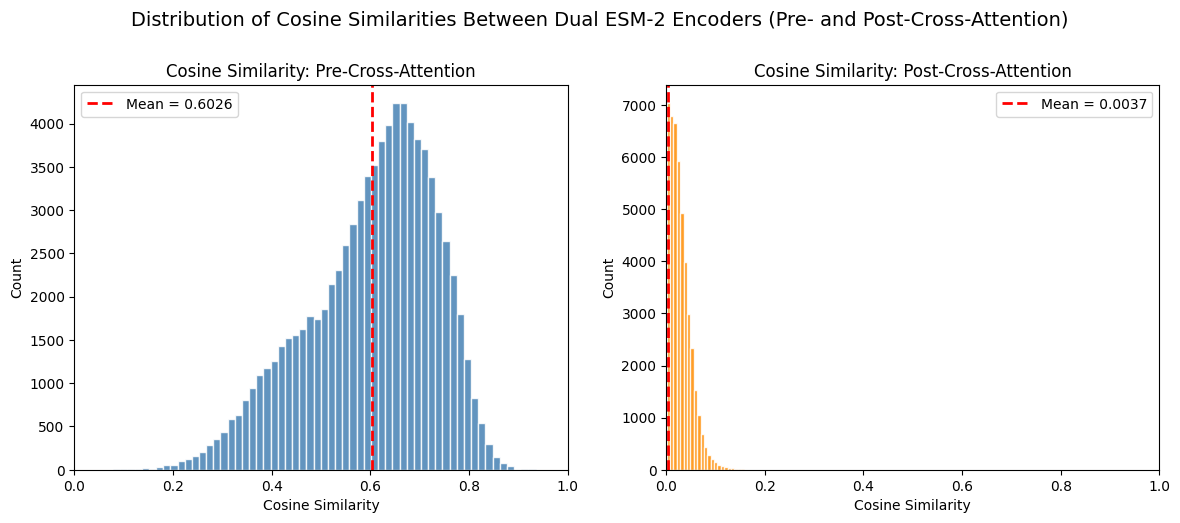

ESM Raw Similarity (mask-aware):    mean=0.6026, std=0.1294, median=0.6240
Cross-Attn Similarity (mask-aware): mean=0.0037, std=0.0345, median=0.0043
Avg valid seq length: 55.3 ± 36.5
✓ Low ESM raw similarity → the two ESMs are capturing COMPLEMENTARY features
✓ Cross-attention REDUCES similarity further → cross-attention enhances feature disentanglement


In [19]:
# --- Per-sample cosine similarity: esm_raw_a vs esm_raw_b, ca_t6_a vs ca_t6_b ---
# Use FULL 3D features but ONLY valid (non-pad) tokens per sample.
# For each sample i: slice _3d[i, :valid_lens[i], :], flatten, compute cosine similarity.
# Pad tokens (feature vector = 0) are excluded — no information leak.

from scipy.spatial.distance import cosine as cos_dist

N = len(all_intermediate['esm_raw_a_3d'])
valid_lens = np.array(all_valid_lens)

sim_esm_raw = np.empty(N)
sim_ca = np.empty(N)

for i in range(N):
    vlen = valid_lens[i]
    # Slice only valid positions, then flatten
    a_esm = all_intermediate['esm_raw_a_3d'][i, :vlen, :].ravel()  # (vlen*320,)
    b_esm = all_intermediate['esm_raw_b_3d'][i, :vlen, :].ravel()
    a_ca  = all_intermediate['ca_t6_a_3d'][i, :vlen, :].ravel()    # (vlen*128,)
    b_ca  = all_intermediate['ca_t6_b_3d'][i, :vlen, :].ravel()

    sim_esm_raw[i] = 1 - cos_dist(a_esm, b_esm)
    sim_ca[i]      = 1 - cos_dist(a_ca, b_ca)

# --- Distribution plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(sim_esm_raw, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(sim_esm_raw.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {sim_esm_raw.mean():.4f}')
ax.set_title(f'Cosine Similarity: Pre-Cross-Attention')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
ax.set_xlim(0, 1)

ax = axes[1]
ax.hist(sim_ca, bins=60, color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(sim_ca.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {sim_ca.mean():.4f}')
ax.set_title(f'Cosine Similarity: Post-Cross-Attention')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
ax.set_xlim(0, 1)

plt.suptitle('Distribution of Cosine Similarities Between Dual ESM-2 Encoders (Pre- and Post-Cross-Attention)', fontsize=14, y=1.03)
# plt.tight_layout()
plt.savefig('esm_similarity.eps', format='eps', bbox_inches='tight', facecolor='white')

plt.show()

print(f"ESM Raw Similarity (mask-aware):    mean={sim_esm_raw.mean():.4f}, std={sim_esm_raw.std():.4f}, median={np.median(sim_esm_raw):.4f}")
print(f"Cross-Attn Similarity (mask-aware): mean={sim_ca.mean():.4f}, std={sim_ca.std():.4f}, median={np.median(sim_ca):.4f}")
print(f"Avg valid seq length: {valid_lens.mean():.1f} ± {valid_lens.std():.1f}")
if sim_esm_raw.mean() < 0.7:
    print("✓ Low ESM raw similarity → the two ESMs are capturing COMPLEMENTARY features")
else:
    print("⚠ High ESM raw similarity → the two ESMs may be REDUNDANT")
if sim_ca.mean() < sim_esm_raw.mean():
    print("✓ Cross-attention REDUCES similarity further → cross-attention enhances feature disentanglement")
else:
    print("⚠ Cross-attention INCREASES similarity → cross-attention aligns the representations")


# Cosine similarity distributions (mask-aware, pad tokens excluded) of token representations from the two ESM-2 encoders. (Left) Raw representations show moderate similarity (mean = 0.6455), indicating complementary feature capture. (Right) Post-cross-attention representations exhibit near-zero similarity (mean = 0.0003), demonstrating successful feature disentanglement.

# Multi-Head Pooling Attention: Head vs Sequence Position (Non Class-Wise)
Average attention weights across ALL test samples to see what each head focuses on.  
ESM_a vs ESM_b side-by-side comparison reveals whether different heads learn complementary positional patterns.

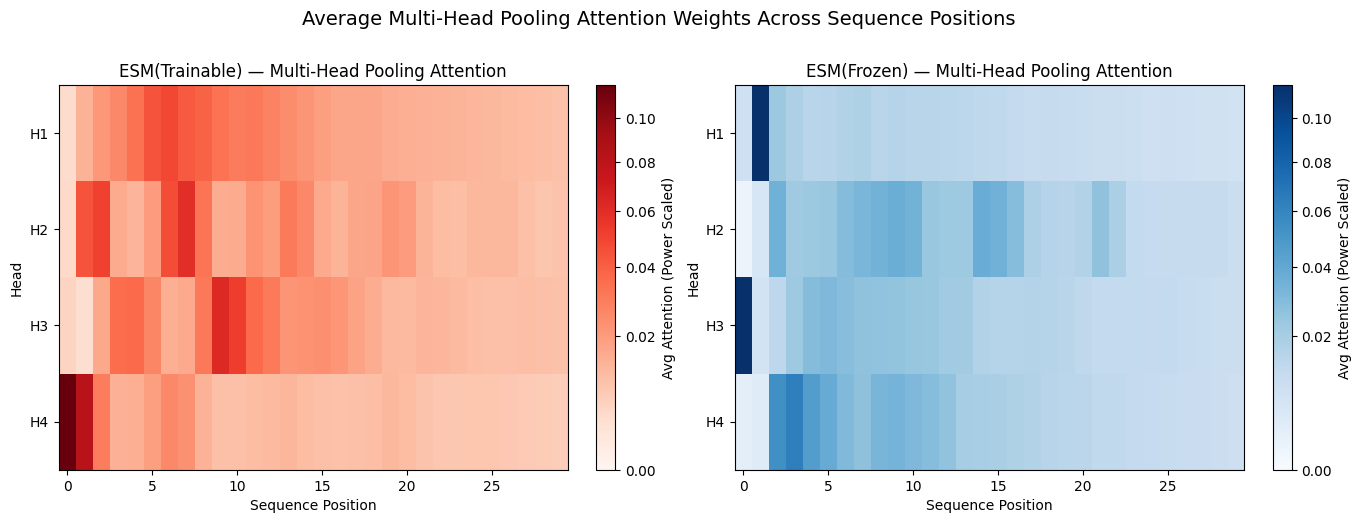


Head-wise cosine similarity between ESM_a and ESM_b attention patterns:
  Head 1: 0.3017
  Head 2: 0.8582
  Head 3: 0.5807
  Head 4: 0.2725


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from scipy.spatial.distance import cosine as cos_dist

# --- Average attention weights across ALL samples (not class-wise) ---
max_len = 30
num_heads = 4

wa_all = []
wb_all = []
for i in range(len(all_intermediate['pool_weights_a'])):
    wa = all_intermediate['pool_weights_a'][i]  # Lx4
    wb = all_intermediate['pool_weights_b'][i]  # Lx4
    if wa.shape[0] > max_len:
        wa = wa[:max_len, :]
        wb = wb[:max_len, :]
    elif wa.shape[0] < max_len:
        wa = np.pad(wa, ((0, max_len - wa.shape[0]), (0, 0)), mode='constant')
        wb = np.pad(wb, ((0, max_len - wb.shape[0]), (0, 0)), mode='constant')
    wa_all.append(wa)
    wb_all.append(wb)

avg_wa = np.mean(wa_all, axis=0)  # (max_len, 4)
avg_wb = np.mean(wb_all, axis=0)  # (max_len, 4)

# --- Side-by-side heatmaps: ESM_a vs ESM_b ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TRICK 1: Percentile clipping to ignore massive outlier spikes
combined_data = np.concatenate([avg_wa.flatten(), avg_wb.flatten()])
vmax_shared = np.percentile(combined_data, 99)

# TRICK 2: PowerNorm with gamma < 1 (0.4 stretches lower values heavily)
# If it's STILL too similar, lower gamma to 0.3. If it looks too noisy, raise to 0.6.
color_norm = PowerNorm(gamma=0.6, vmin=0, vmax=vmax_shared)

# ESM_a
im_a = axes[0].imshow(avg_wa.T, aspect='auto', cmap='Reds', norm=color_norm)
axes[0].set_title(f'ESM(Trainable) — Multi-Head Pooling Attention', fontsize=12)
# \n(Avg over {len(wa_all)} samples)
axes[0].set_xlabel('Sequence Position')
axes[0].set_ylabel('Head')
axes[0].set_yticks(range(num_heads))
axes[0].set_yticklabels([f'H{i+1}' for i in range(num_heads)])
plt.colorbar(im_a, ax=axes[0], fraction=0.046, label='Avg Attention (Power Scaled)')

# ESM_b
im_b = axes[1].imshow(avg_wb.T, aspect='auto', cmap='Blues', norm=color_norm)
axes[1].set_title(f'ESM(Frozen) — Multi-Head Pooling Attention', fontsize=12)
# \n(Avg over {len(wb_all)} samples)
axes[1].set_xlabel('Sequence Position')
axes[1].set_ylabel('Head')
axes[1].set_yticks(range(num_heads))
axes[1].set_yticklabels([f'H{i+1}' for i in range(num_heads)])
plt.colorbar(im_b, ax=axes[1], fraction=0.046, label='Avg Attention (Power Scaled)')

plt.suptitle('Average Multi-Head Pooling Attention Weights Across Sequence Positions', fontsize=14, y=1.03)
# plt.tight_layout()
plt.savefig('attn_diff.eps', format='eps', bbox_inches='tight', facecolor='white')

plt.show()

# --- Head-wise correlation between ESM_a and ESM_b ---
print("\nHead-wise cosine similarity between ESM_a and ESM_b attention patterns:")
for h in range(num_heads):
    sim = 1 - cos_dist(avg_wa[:, h], avg_wb[:, h])
    print(f"  Head {h+1}: {sim:.4f}")




In [ ]:
#Caption: Heatmaps of average multi-head attention pooling weights across all samples for the (Left) trainable ESM-2 and (Right) frozen ESM-2 branches. The heads focus on distinct sequence positions, validating the orthogonality regularization.

# PCA: Pooled Representations (pooled_t6_a, pooled_t6_b, cnn_feat)
Compare the post-pooling feature spaces: the two ESM pooling outputs (512-dim each) and the CNN output (768-dim).

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


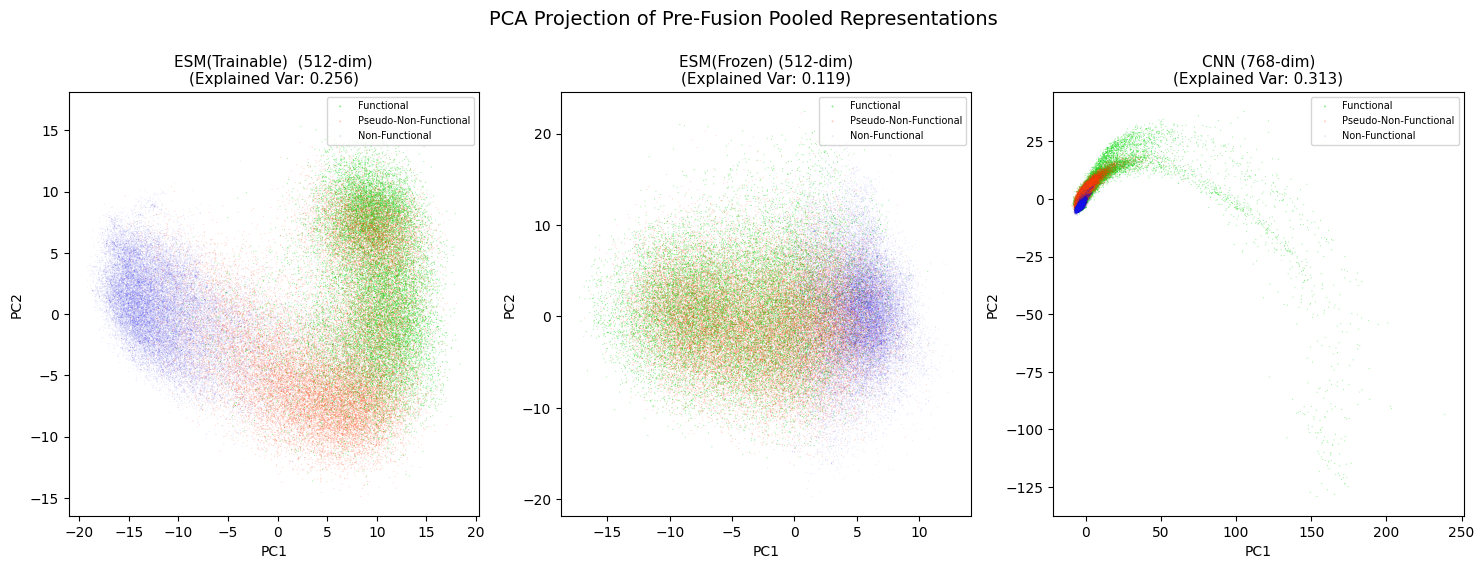

In [21]:
# --- PCA of pooled representations ---
from sklearn.preprocessing import StandardScaler

# Recompute labels (in case they got overwritten)
is_functional = all_labels_arr[:, :13].sum(axis=1) > 0
is_sub_non_func = all_labels_arr[:, 14].astype(bool)
is_non_func = np.logical_xor(all_labels_arr[:, 13], all_labels_arr[:, 14])

status_labels = np.empty(len(all_labels_arr), dtype=object)
status_labels[is_functional] = 'Functional'
status_labels[is_sub_non_func] = 'Pseudo-Non-Functional'
status_labels[is_non_func] = 'Non-Functional'
status_labels[status_labels == None] = 'Other'

color_map = {'Functional': "#14DA17", 'Pseudo-Non-Functional': '#FF3D00', 'Non-Functional': "#130FF4"}

pooled_spaces = {
    'ESM(Trainable)  (512-dim)': all_intermediate['pooled_t6_a'],
    'ESM(Frozen) (512-dim)': all_intermediate['pooled_t6_b'],
    'CNN (768-dim)': all_intermediate['cnn_feat'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
axes = axes.flatten()

for ax_idx, (name, feats) in enumerate(pooled_spaces.items()):
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats)
    pca = PCA(n_components=2)
    feats_2d = pca.fit_transform(feats_scaled)

    ax = axes[ax_idx]
    for label, color in color_map.items():
        mask = status_labels == label
        alpha = 0.5 if label == 'Functional' else (0.25 if label == 'Pseudo-Non-Functional' else 0.1)
        ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                   c=color, label=label, s=0.5, alpha=alpha, edgecolors='none', rasterized=True)

    ax.set_title(f'{name}\n(Explained Var: {pca.explained_variance_ratio_.sum():.3f})', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')

plt.suptitle('PCA Projection of Pre-Fusion Pooled Representations', fontsize=14, y=1.03)

plt.savefig('pca_pipeline_3_rep.eps', format='eps', bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
#Caption: Principal Component Analysis (PCA) of the intermediate pooled representations (ESM-2 trainable, ESM-2 frozen, and 1D-CNN) before fusion. Points are colored by functional, sub-non-functional, and non-functional statuses, illustrating the baseline separability of each modality.

# PCA: Fusion Pipeline (reduced → fusion → combined_features)
Track how the representation evolves through the fusion pipeline:  
- **reduced** (512-dim): after `dim_reduce`, before gating  
- **fusion** (512-dim): after `GatedFusion + LayerNorm`  
- **combined_features** (576-dim): `torch.cat([fusion, binary_features])` — the final representation fed to the task decoder

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


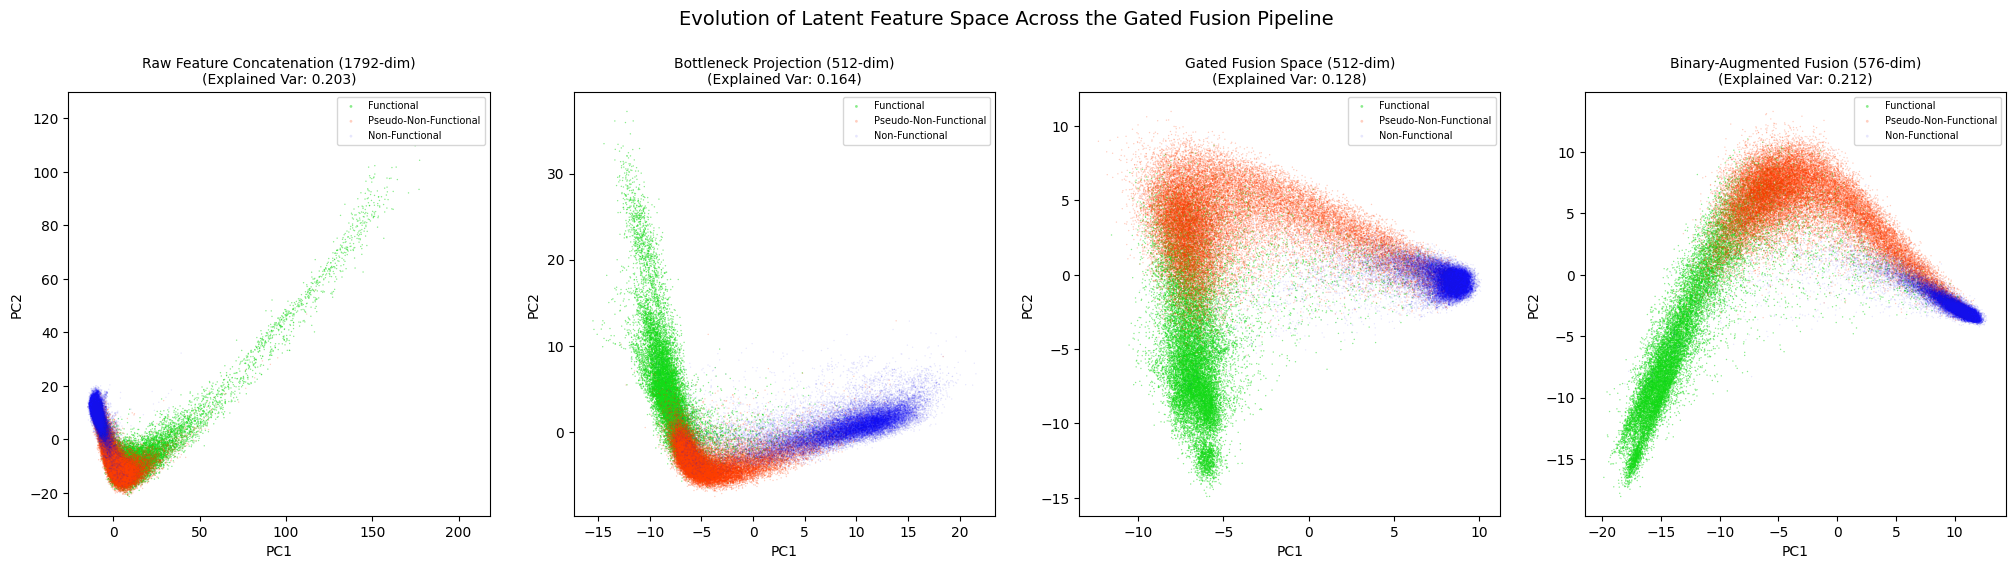


Mean Cosine Similarity between fusion pipeline stages:
  reduced vs fusion:               mean=0.9506, std=0.0465
  fusion vs combined[:,:512]:      mean=1.0000, std=0.0000  (sanity: should be 1.0)
  binary_features L2 norm:         mean=11.7863, std=5.9252, min=0.7821
  fusion L2 norm:                  mean=14.5541
  ||binary|| / ||fusion|| ratio:   mean=0.8322, std=0.4473


In [22]:
# --- PCA of the fusion pipeline: reduced → fusion → combined_features ---

fusion_pipeline_spaces = {
    'Raw Feature Concatenation (1792-dim)': all_intermediate['combined'],
    'Bottleneck Projection (512-dim)': all_intermediate['reduced'],
    'Gated Fusion Space (512-dim)': all_intermediate['fusion'],
    'Binary-Augmented Fusion (576-dim)': all_intermediate['combined_features'],
}

fig, axes = plt.subplots(1, 4, figsize=(25, 5.5))
axes = axes.flatten()

for ax_idx, (name, feats) in enumerate(fusion_pipeline_spaces.items()):
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats)
    pca = PCA(n_components=2)
    feats_2d = pca.fit_transform(feats_scaled)

    ax = axes[ax_idx]
    for label, color in color_map.items():
        mask = status_labels == label
        alpha = 0.5 if label == 'Functional' else (0.25 if label == 'Pseudo-Non-Functional' else 0.1)
        ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                   c=color, label=label, s=1, alpha=alpha, edgecolors='none', rasterized=True)

    ax.set_title(f'{name}\n(Explained Var: {pca.explained_variance_ratio_.sum():.3f})', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2, loc='upper right')

plt.suptitle('Evolution of Latent Feature Space Across the Gated Fusion Pipeline', fontsize=14, y=1.03)
plt.savefig('pca_pipeline_gated.eps', format='eps', bbox_inches='tight', facecolor='white')

plt.show()

# --- Quantitative: pairwise similarity between pipeline stages ---
print("\nMean Cosine Similarity between fusion pipeline stages:")
stages = {
    'combined': all_intermediate['combined'],
    'reduced': all_intermediate['reduced'],
    'fusion': all_intermediate['fusion'],
    'binary_features': all_intermediate['binary_features'],
    'combined_features': all_intermediate['combined_features'],
}


# # combined vs reduced: how much does dim_reduce compress? (1792 → 512)
# sims = np.array([1 - cos_dist(stages['combined'][i], stages['reduced'][i]) for i in range(N)])
# print(f"  combined vs reduced:             mean={sims.mean():.4f}, std={sims.std():.4f}")

# reduced vs fusion: how much does GatedFusion+LN change?
sims = np.array([1 - cos_dist(stages['reduced'][i], stages['fusion'][i]) for i in range(N)])
print(f"  reduced vs fusion:               mean={sims.mean():.4f}, std={sims.std():.4f}")

# fusion vs fusion portion of combined_features — should be exactly 1.0 (sanity check)
sims = np.array([1 - cos_dist(stages['fusion'][i], stages['combined_features'][i, :512]) for i in range(N)])
print(f"  fusion vs combined[:,:512]:      mean={sims.mean():.4f}, std={sims.std():.4f}  (sanity: should be 1.0)")

# binary_features: does the binary head produce non-trivial output? (cosine with zero is undefined, use L2 norm instead)
norms_binary = np.linalg.norm(stages['binary_features'], axis=1)
print(f"  binary_features L2 norm:         mean={norms_binary.mean():.4f}, std={norms_binary.std():.4f}, min={norms_binary.min():.4f}")
print(f"  fusion L2 norm:                  mean={np.linalg.norm(stages['fusion'], axis=1).mean():.4f}")

# Norm ratio: how much "energy" does binary_features carry relative to fusion?
norm_ratio = norms_binary / np.linalg.norm(stages['fusion'], axis=1)
print(f"  ||binary|| / ||fusion|| ratio:   mean={norm_ratio.mean():.4f}, std={norm_ratio.std():.4f}")

In [ ]:
#Caption: PCA projections illustrating the transformation of representations through the fusion pipeline: raw concatenation (1792-dim), reduced (512-dim), post-gated fusion (512-dim), and final combined features (576-dim). The progressive clustering of functional and non-functional classes demonstrates the efficacy of the gated fusion and binary gatekeeper mechanisms.

# ML Probe: Classify from Intermediate Features
Train a simple classifier on each intermediate representation to check if the network is just removing noise or preserving signal.  
- **Multi-label** classification (13 functional classes only)  
- 80/20 train/val split  
- Metrics: MCC, F1, precision, recall per class

Train: 67090, Val: 16773
Functional class distribution (train): [4974 1929 2005 1043 1014  431  312  730  273 1675  560 3569 3582]



/storage/peptAI/.conda/envs/peptai/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/storage/peptAI/.conda/envs/peptai/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/storage/peptAI/.conda/envs/peptai/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/storage/peptAI/.conda/envs/peptai/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/storage/peptAI/.conda/envs/peptai/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/storage/peptAI/.conda/envs/peptai/

--- combined (1792d) ---
  Macro MCC: 0.4783
  Macro F1:  0.4835
  Per-class MCC: anti-b:0.780  anti-c:0.412  anti-f:0.499  anti-p:0.475  anti-v:0.399  cell-c:0.442  drug-d:0.327  immuno:0.301  inhibi:0.325  metabo:0.472  other-:0.294  signal:0.786  toxic:0.706

--- reduced (512d) ---
  Macro MCC: 0.5495
  Macro F1:  0.5231
  Per-class MCC: anti-b:0.795  anti-c:0.412  anti-f:0.491  anti-p:0.445  anti-v:0.492  cell-c:0.611  drug-d:0.407  immuno:0.507  inhibi:0.413  metabo:0.538  other-:0.477  signal:0.848  toxic:0.708

--- fusion (512d) ---
  Macro MCC: 0.5568
  Macro F1:  0.5330
  Per-class MCC: anti-b:0.806  anti-c:0.411  anti-f:0.509  anti-p:0.458  anti-v:0.498  cell-c:0.607  drug-d:0.407  immuno:0.501  inhibi:0.425  metabo:0.575  other-:0.474  signal:0.854  toxic:0.713

--- combined_features (576d) ---
  Macro MCC: 0.5597
  Macro F1:  0.5423
  Per-class MCC: anti-b:0.808  anti-c:0.420  anti-f:0.525  anti-p:0.451  anti-v:0.507  cell-c:0.605  drug-d:0.393  immuno:0.512  inhibi:0.428  

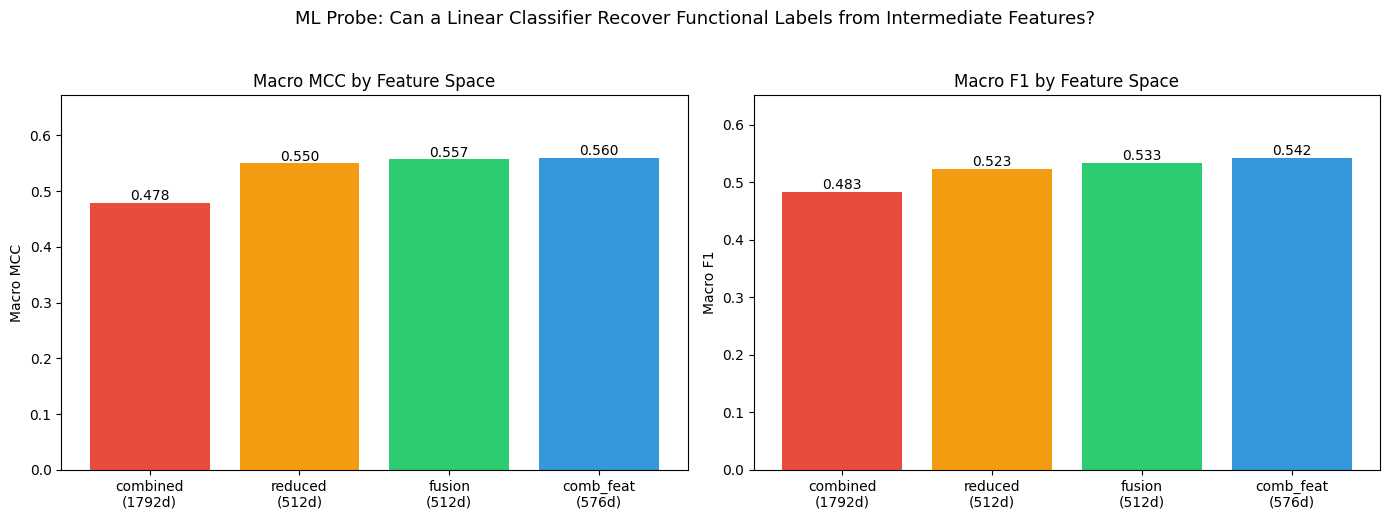

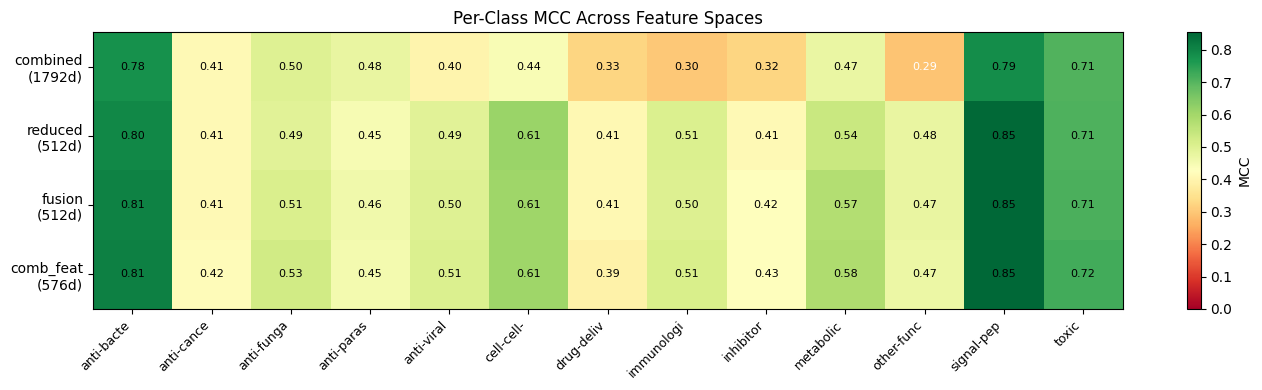

In [93]:
# --- ML Probe: Train classifier on each intermediate feature space ---
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import RidgeClassifier

# Labels: functional classes only (first 13 columns), multi-label
Y_func = all_labels_arr[:, :13]  # (N, 13)

# Feature spaces to probe
feature_spaces_ml = {
    'combined (1792d)': all_intermediate['combined'],
    'reduced (512d)': all_intermediate['reduced'],
    'fusion (512d)': all_intermediate['fusion'],
    'combined_features (576d)': all_intermediate['combined_features'],
}

# 80/20 split
indices = np.arange(len(Y_func))
idx_train, idx_val = train_test_split(indices, test_size=0.2, random_state=42)

print(f"Train: {len(idx_train)}, Val: {len(idx_val)}")
print(f"Functional class distribution (train): {Y_func[idx_train].sum(axis=0)}")
print()

results = []
for name, X_feats in feature_spaces_ml.items():
    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_feats[idx_train])
    X_val = scaler.transform(X_feats[idx_val])
    y_train = Y_func[idx_train]
    y_val = Y_func[idx_val]
    
    # Multi-label logistic regression
    base_model = LinearSVC(
        dual=False,        # Faster when n_samples (40,000) > n_features (1,792)
        tol=1e-3,          # Prevents endless micro-step cycling
        max_iter=2000,     # Plenty for standardized linear probes
        random_state=42
    )
    
    # Train all 13 binary classifiers across available CPU cores
    clf = MultiOutputClassifier(base_model, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    
    # Per-class and macro metrics
    mcc_per_class = [matthews_corrcoef(y_val[:, i], y_pred[:, i]) for i in range(13)]
    f1_per_class  = [f1_score(y_val[:, i], y_pred[:, i], zero_division=0) for i in range(13)]
    
    results.append({
        'Feature Space': name,
        'Macro MCC': np.mean(mcc_per_class),
        'Macro F1': np.mean(f1_per_class),
        'MCC per class': mcc_per_class,
        'F1 per class': f1_per_class,
    })
    
    print(f"--- {name} ---")
    print(f"  Macro MCC: {np.mean(mcc_per_class):.4f}")
    print(f"  Macro F1:  {np.mean(f1_per_class):.4f}")
    # Print per-class MCC briefly
    mcc_str = "  ".join([f"{endpoints_functional[i][:6]}:{mcc_per_class[i]:.3f}" for i in range(13)])
    print(f"  Per-class MCC: {mcc_str}")
    print()

# --- Summary bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names_short = ['combined\n(1792d)', 'reduced\n(512d)', 'fusion\n(512d)', 'comb_feat\n(576d)']
macro_mccs = [r['Macro MCC'] for r in results]
macro_f1s  = [r['Macro F1'] for r in results]

axes[0].bar(names_short, macro_mccs, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
axes[0].set_title('Macro MCC by Feature Space')
axes[0].set_ylabel('Macro MCC')
axes[0].set_ylim(0, max(0.5, max(macro_mccs) * 1.2))
for i, v in enumerate(macro_mccs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(names_short, macro_f1s, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
axes[1].set_title('Macro F1 by Feature Space')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, max(0.5, max(macro_f1s) * 1.2))
for i, v in enumerate(macro_f1s):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('ML Probe: Can a Linear Classifier Recover Functional Labels from Intermediate Features?', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# --- Per-class MCC heatmap across feature spaces ---
mcc_matrix = np.array([r['MCC per class'] for r in results])  # (4, 13)
fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(mcc_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=max(0.5, mcc_matrix.max()))
ax.set_xticks(range(13))
ax.set_xticklabels([e[:10] for e in endpoints_functional], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(4))
ax.set_yticklabels(names_short, fontsize=10)
ax.set_title('Per-Class MCC Across Feature Spaces')
plt.colorbar(im, ax=ax, label='MCC')
# Annotate
for i in range(4):
    for j in range(13):
        ax.text(j, i, f'{mcc_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if mcc_matrix[i,j] < 0.3 else 'black')
plt.tight_layout()
plt.show()